In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots with larger fonts
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set default font sizes for all plots
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.labelsize': 16,      # Axis labels (x, y labels)
    'axes.titlesize': 16,      # Keep titles as they are
    'xtick.labelsize': 14,     # X-axis tick labels
    'ytick.labelsize': 14,     # Y-axis tick labels
    'legend.fontsize': 13,     # Legend text
    'figure.titlesize': 16     # Figure titles
})

print("📊 Model Extraction Evaluation - Libraries Loaded Successfully!")

📊 Model Extraction Evaluation - Libraries Loaded Successfully!


In [2]:
class ModelExtractionEvaluator:
    """Evaluate and compare the effectiveness of different LLM models in extracting regulatory constraints."""
    
    def __init__(self):
        self.df = None
        self.model_stats = None
        self.evaluation_results = {}
        self.excluded_models = set()
        
    def load_data(self, csv_path: str):
        """Load the combined filtered constraints data."""
        try:
            self.df = pd.read_csv(csv_path)
            print(f"✅ Loaded {len(self.df)} filtered constraints from {csv_path}")
            print(f"📋 Columns: {list(self.df.columns)}")
            
            # Show available models
            if 'model_name' in self.df.columns:
                models = self.df['model_name'].unique()
                print(f"📊 Available models: {sorted(models)}")
            
            return True
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return False
    
    def exclude_models(self, models_to_exclude: list):
        """
        Exclude specified models from analysis.
        
        Args:
            models_to_exclude: List of model names to exclude from evaluation
        """
        if self.df is None:
            print("❌ No data loaded. Please load data first.")
            return
        
        # Store excluded models
        self.excluded_models = set(models_to_exclude)
        
        # Filter out excluded models
        original_count = len(self.df)
        self.df = self.df[~self.df['model_name'].isin(models_to_exclude)].copy()
        filtered_count = len(self.df)
        
        excluded_count = original_count - filtered_count
        
        print(f"🚫 EXCLUDED MODELS:")
        for model in models_to_exclude:
            model_count = original_count - len(self.df[self.df['model_name'] != model]) if model in self.excluded_models else 0
            print(f"   • {model}")
        
        print(f"\n📊 FILTERING RESULTS:")
        print(f"   Original constraints: {original_count}")
        print(f"   Excluded constraints: {excluded_count}")
        print(f"   Remaining constraints: {filtered_count}")
        print(f"   Remaining models: {sorted(self.df['model_name'].unique())}")
        
        # Reset any previous analysis
        self.model_stats = None
        self.evaluation_results = {}

    def analyze_model_performance(self):
        """Analyze the performance of each model in extracting constraints."""
        if self.df is None:
            print("❌ No data loaded. Please load data first.")
            return
        
        if len(self.df) == 0:
            print("❌ No data remaining after filtering. Please check excluded models.")
            return
        
        print("🔍 Analyzing model performance...")
        
        # Check which columns actually exist in the dataset
        available_columns = self.df.columns.tolist()
        print(f"📋 Available columns: {available_columns}")
        
        # Show models being analyzed
        remaining_models = sorted(self.df['model_name'].unique())
        print(f"📊 Models being analyzed: {remaining_models}")
        
        if self.excluded_models:
            print(f"🚫 Excluded from analysis: {sorted(self.excluded_models)}")
        
        # Build aggregation dictionary based on available columns
        agg_dict = {
            'requirement': 'count',
            'total_score': ['mean', 'std', 'min', 'max'],
            'numerical_value': lambda x: x.notna().sum(),
            'constraint_type': 'nunique',
            'related_domains': lambda x: x.str.split(';').str.len().mean() if x.notna().any() else 0
        }
        
        # Add confidence_score analysis only if column exists
        if 'confidence_score' in available_columns:
            agg_dict['confidence_score'] = ['mean', 'std']
            print("✓ Including confidence_score analysis")
        else:
            print("⚠️  confidence_score column not found - skipping confidence analysis")
        
        # Perform aggregation
        model_stats = self.df.groupby('model_name').agg(agg_dict).round(4)
        
        # Flatten column names based on what was actually aggregated
        if 'confidence_score' in available_columns:
            model_stats.columns = [
                'total_constraints', 'score_mean', 'score_std', 'score_min', 'score_max',
                'confidence_mean', 'confidence_std', 'numerical_constraints', 
                'unique_constraint_types', 'avg_domains_per_constraint'
            ]
        else:
            model_stats.columns = [
                'total_constraints', 'score_mean', 'score_std', 'score_min', 'score_max',
                'numerical_constraints', 'unique_constraint_types', 'avg_domains_per_constraint'
            ]
        
        # Add percentage of total
        model_stats['percentage_of_total'] = (model_stats['total_constraints'] / len(self.df) * 100).round(2)
        
        # Sort by total constraints
        model_stats = model_stats.sort_values('total_constraints', ascending=False)
        
        self.model_stats = model_stats
        
        print(f"\n📊 MODEL PERFORMANCE SUMMARY:")
        print("=" * 80)
        
        # Adjust header based on available columns
        if 'confidence_score' in available_columns:
            print(f"{'Model':<25} {'Count':<8} {'%':<6} {'Avg Score':<10} {'Confidence':<12} {'Numerical':<10} {'Types':<8}")
        else:
            print(f"{'Model':<25} {'Count':<8} {'%':<6} {'Avg Score':<10} {'Numerical':<10} {'Types':<8}")
        
        print("-" * 80)
        
        for model, stats in model_stats.iterrows():
            if 'confidence_score' in available_columns:
                print(f"{model:<25} {stats['total_constraints']:<8} {stats['percentage_of_total']:<6.1f} "
                      f"{stats['score_mean']:<10.3f} {stats['confidence_mean']:<12.3f} "
                      f"{stats['numerical_constraints']:<10} {stats['unique_constraint_types']:<8}")
            else:
                print(f"{model:<25} {stats['total_constraints']:<8} {stats['percentage_of_total']:<6.1f} "
                      f"{stats['score_mean']:<10.3f} {stats['numerical_constraints']:<10} {stats['unique_constraint_types']:<8}")
        
        return model_stats
    
    def create_individual_plots(self):
        """Create individual plots for better visibility and analysis."""
        if self.model_stats is None:
            self.analyze_model_performance()
        
        models = self.model_stats.index
        colors = sns.color_palette("husl", len(models))
        
        # Plot 1: Total Constraints Extracted by Model
        plt.figure(figsize=(12, 8))
        counts = self.model_stats['total_constraints']
        bars = plt.bar(models, counts, color=colors)
        plt.title('Total Constraints Extracted by Model', fontsize=16, fontweight='bold')
        plt.xlabel('Model Name', fontsize=16)
        plt.ylabel('Number of Constraints', fontsize=16)
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(fontsize=14)
        
        # Add value labels on bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        plt.tight_layout()
        plt.grid(True, alpha=0.3, axis='y')
        plt.show()
        
        # Plot 2: Percentage Distribution - FIXED
        plt.figure(figsize=(10, 8))
        colors_pie = sns.color_palette("Set3", len(models))
        wedges, texts, autotexts = plt.pie(counts, labels=models, autopct='%1.1f%%', 
                                          colors=colors_pie, startangle=90)
        plt.title('Distribution of Extracted Constraints', fontsize=16, fontweight='bold')
        
        # Fix text readability - make percentage text black and bold
        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(12)
            autotext.set_bbox(dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Make model labels more readable
        for text in texts:
            text.set_fontsize(12)
            text.set_fontweight('bold')
        
        plt.show()
        
        # Plot 3: Box Plot of Relevance Scores
        plt.figure(figsize=(12, 8))
        model_scores = [self.df[self.df['model_name'] == model]['total_score'].values 
                       for model in models]
        box_plot = plt.boxplot(model_scores, labels=models, patch_artist=True)
        
        # Color the boxes
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        plt.title('Relevance Score Distribution by Model', fontsize=16, fontweight='bold')
        plt.xlabel('Model Name', fontsize=16)
        plt.ylabel('Total Score', fontsize=16)
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Plot 4: Numerical Constraints Comparison
        plt.figure(figsize=(12, 8))
        numerical_counts = self.model_stats['numerical_constraints']
        bars = plt.bar(models, numerical_counts, color=sns.color_palette("viridis", len(models)))
        plt.title('Constraints with Numerical Values by Model', fontsize=16, fontweight='bold')
        plt.xlabel('Model Name', fontsize=16)
        plt.ylabel('Number of Numerical Constraints', fontsize=16)
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(fontsize=14)
        
        # Add value labels
        for bar, count in zip(bars, numerical_counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        # Plot 5: Constraint Type Diversity
        plt.figure(figsize=(12, 8))
        type_diversity = self.model_stats['unique_constraint_types']
        bars = plt.bar(models, type_diversity, color=sns.color_palette("plasma", len(models)))
        plt.title('Constraint Type Diversity by Model', fontsize=16, fontweight='bold')
        plt.xlabel('Model Name', fontsize=16)
        plt.ylabel('Number of Unique Constraint Types', fontsize=16)
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(fontsize=14)
        
        # Add value labels
        for bar, count in zip(bars, type_diversity):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        # Plot 6: Extraction Efficiency
        plt.figure(figsize=(12, 8))
        efficiency = self.model_stats['total_constraints'] / self.model_stats['unique_constraint_types']
        bars = plt.bar(models, efficiency, color=sns.color_palette("coolwarm", len(models)))
        plt.title('Extraction Efficiency (Constraints per Constraint Type)', fontsize=16, fontweight='bold')
        plt.xlabel('Model Name', fontsize=16)
        plt.ylabel('Constraints per Constraint Type', fontsize=16)
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(fontsize=14)
        
        # Add value labels
        for bar, eff in zip(bars, efficiency):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{eff:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        print("✅ All individual plots have been displayed!")
        return True
    
    def create_advanced_individual_plots(self):
        """Create advanced individual analysis plots."""
        if self.model_stats is None:
            self.analyze_model_performance()
        
        models = self.model_stats.index
        colors = sns.color_palette("husl", len(models))
        
        # Plot 1: Violin Plot of Scores
        plt.figure(figsize=(14, 8))
        score_data = [self.df[self.df['model_name'] == model]['total_score'].values for model in models]
        parts = plt.violinplot(score_data, positions=range(len(models)), showmeans=True, showmedians=True)
        
        # Color the violin plots
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.7)
        
        plt.xticks(range(len(models)), models, rotation=45, ha='right', fontsize=14)
        plt.yticks(fontsize=14)
        plt.title('Score Distribution by Model (Violin Plot)', fontsize=16, fontweight='bold')
        plt.xlabel('Model Name', fontsize=16)
        plt.ylabel('Total Score', fontsize=16)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Plot 2: Correlation Heatmap
        plt.figure(figsize=(10, 8))
        correlation_data = self.model_stats[['total_constraints', 'score_mean', 'numerical_constraints', 
                                           'unique_constraint_types']].corr()
        sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, 
                   square=True, cbar_kws={'shrink': 0.8}, fmt='.3f', annot_kws={'fontsize': 12})
        plt.title('Model Performance Metrics Correlation', fontsize=16, fontweight='bold')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Plot 3: Quality vs Quantity Scatter Plot
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(self.model_stats['total_constraints'], 
                             self.model_stats['score_mean'],
                             s=self.model_stats['numerical_constraints'] * 5,
                             c=range(len(models)), cmap='viridis', alpha=0.7)
        
        # Add model labels
        for i, model in enumerate(models):
            plt.annotate(model, 
                        (self.model_stats.loc[model, 'total_constraints'],
                         self.model_stats.loc[model, 'score_mean']),
                        xytext=(5, 5), textcoords='offset points', fontsize=12,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        
        plt.xlabel('Total Constraints Extracted', fontsize=16)
        plt.ylabel('Average Relevance Score', fontsize=16)
        plt.title('Model Performance: Quality vs Quantity\n(Bubble size = Numerical Constraints)', 
                 fontsize=16, fontweight='bold')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.grid(True, alpha=0.3)
        cbar = plt.colorbar(scatter, label='Model Index')
        cbar.ax.tick_params(labelsize=12)
        cbar.set_label('Model Index', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Plot 4: Stacked Bar Chart of Top Constraint Types
        plt.figure(figsize=(14, 8))
        if 'constraint_type' in self.df.columns:
            # Get top constraint types
            top_types = self.df['constraint_type'].value_counts().head(8).index
            
            # Create matrix for stacked bar
            stack_data = []
            for ctype in top_types:
                type_counts = []
                for model in models:
                    count = len(self.df[(self.df['model_name'] == model) & 
                                       (self.df['constraint_type'] == ctype)])
                    type_counts.append(count)
                stack_data.append(type_counts)
            
            # Create stacked bar chart
            bottom = np.zeros(len(models))
            colors_stack = sns.color_palette("Set3", len(top_types))
            
            for i, (ctype, counts) in enumerate(zip(top_types, stack_data)):
                plt.bar(models, counts, bottom=bottom, label=ctype, 
                       color=colors_stack[i], alpha=0.8)
                bottom += counts
            
            plt.title('Top Constraint Types by Model (Stacked)', fontsize=16, fontweight='bold')
            plt.xlabel('Model Name', fontsize=16)
            plt.ylabel('Number of Constraints', fontsize=16)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
            plt.xticks(rotation=45, ha='right', fontsize=14)
            plt.yticks(fontsize=14)
            plt.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()
        
        # Plot 5: Performance Radar Chart for Top Models
        plt.figure(figsize=(10, 10))
        
        # Select top 5 models by total constraints
        top_models = models[:5]
        
        # Normalize metrics to 0-1 scale for radar chart
        metrics = ['total_constraints', 'score_mean', 'numerical_constraints', 'unique_constraint_types']
        metric_labels = ['Total\nConstraints', 'Average\nScore', 'Numerical\nConstraints', 'Constraint\nTypes']
        
        # Calculate angles for each metric
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle
        
        ax = plt.subplot(111, projection='polar')
        
        for i, model in enumerate(top_models):
            values = []
            for metric in metrics:
                value = self.model_stats.loc[model, metric]
                max_val = self.model_stats[metric].max()
                normalized = value / max_val if max_val > 0 else 0
                values.append(normalized)
            
            values += values[:1]  # Complete the circle
            
            ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
            ax.fill(angles, values, alpha=0.25, color=colors[i])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metric_labels, fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylim(0, 1)
        ax.set_title('Performance Comparison - Top 5 Models\n(Normalized Metrics)', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), fontsize=12)
        plt.tight_layout()
        plt.show()
        
        print("✅ All advanced individual plots have been displayed!")
        return True
    
    def create_count_comparison_plots(self):
        """Create various plots to compare constraint extraction counts by model."""
        if self.model_stats is None:
            self.analyze_model_performance()
        
        # Create figure with subplots
        fig = plt.figure(figsize=(20, 15))
        
        # 1. Bar plot of total constraints
        plt.subplot(2, 3, 1)
        models = self.model_stats.index
        counts = self.model_stats['total_constraints']
        bars = plt.bar(models, counts, color=sns.color_palette("husl", len(models)))
        plt.title('Total Constraints Extracted by Model', fontsize=14, fontweight='bold')
        plt.xlabel('Model Name', fontsize=12)
        plt.ylabel('Number of Constraints', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add value labels on bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # 2. Pie chart of percentage distribution - FIXED
        plt.subplot(2, 3, 2)
        colors = sns.color_palette("husl", len(models))
        wedges, texts, autotexts = plt.pie(counts, labels=models, autopct='%1.1f%%', 
                                          colors=colors, startangle=90)
        plt.title('Distribution of Extracted Constraints', fontsize=14, fontweight='bold')
        
        # Fix percentage text visibility in subplot
        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(10)
            autotext.set_bbox(dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
        
        for text in texts:
            text.set_fontsize(9)
        
        # 3. Box plot of relevance scores by model
        plt.subplot(2, 3, 3)
        model_scores = [self.df[self.df['model_name'] == model]['total_score'].values 
                       for model in models]
        box_plot = plt.boxplot(model_scores, labels=models, patch_artist=True)
        
        # Color the boxes
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        plt.title('Relevance Score Distribution by Model', fontsize=14, fontweight='bold')
        plt.xlabel('Model Name', fontsize=12)
        plt.ylabel('Total Score', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        
        # 4. Numerical constraints comparison
        plt.subplot(2, 3, 4)
        numerical_counts = self.model_stats['numerical_constraints']
        bars = plt.bar(models, numerical_counts, color=sns.color_palette("viridis", len(models)))
        plt.title('Constraints with Numerical Values by Model', fontsize=14, fontweight='bold')
        plt.xlabel('Model Name', fontsize=12)
        plt.ylabel('Number of Numerical Constraints', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add value labels
        for bar, count in zip(bars, numerical_counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # 5. Constraint type diversity
        plt.subplot(2, 3, 5)
        type_diversity = self.model_stats['unique_constraint_types']
        bars = plt.bar(models, type_diversity, color=sns.color_palette("plasma", len(models)))
        plt.title('Constraint Type Diversity by Model', fontsize=14, fontweight='bold')
        plt.xlabel('Model Name', fontsize=12)
        plt.ylabel('Number of Unique Constraint Types', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add value labels
        for bar, count in zip(bars, type_diversity):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                    str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # 6. Combined efficiency score (constraints per unique type)
        plt.subplot(2, 3, 6)
        efficiency = self.model_stats['total_constraints'] / self.model_stats['unique_constraint_types']
        bars = plt.bar(models, efficiency, color=sns.color_palette("coolwarm", len(models)))
        plt.title('Extraction Efficiency\n(Constraints per Type)', fontsize=14, fontweight='bold')
        plt.xlabel('Model Name', fontsize=12)
        plt.ylabel('Constraints per Constraint Type', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add value labels
        for bar, eff in zip(bars, efficiency):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{eff:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        plt.tight_layout()
        plt.suptitle('LLM Model Performance Comparison - Regulatory Constraint Extraction', 
                    fontsize=16, fontweight='bold', y=0.98)
        plt.show()
        
        return fig
    
    def generate_model_ranking(self):
        """Generate a comprehensive ranking of models based on multiple criteria."""
        if self.model_stats is None:
            self.analyze_model_performance()
        
        print("\n🏆 MODEL RANKING ANALYSIS")
        print("=" * 60)
        
        # Define ranking criteria with weights - adjust based on available columns
        available_columns = self.model_stats.columns.tolist()
        
        if 'confidence_mean' in available_columns:
            criteria = {
                'total_constraints': 0.25,      # Quantity
                'score_mean': 0.25,             # Quality (total_score)
                'confidence_mean': 0.20,        # Confidence in extraction
                'numerical_constraints': 0.15,  # Actionability
                'unique_constraint_types': 0.10, # Diversity
                'percentage_of_total': 0.05     # Relative contribution
            }
        else:
            criteria = {
                'total_constraints': 0.30,      # Quantity (higher weight without confidence)
                'score_mean': 0.30,             # Quality (higher weight)
                'numerical_constraints': 0.20,  # Actionability
                'unique_constraint_types': 0.15, # Diversity
                'percentage_of_total': 0.05     # Relative contribution
            }
        
        # Normalize each criterion to 0-1 scale
        ranking_df = self.model_stats.copy()
        
        for criterion in criteria.keys():
            if criterion in ranking_df.columns:
                max_val = ranking_df[criterion].max()
                min_val = ranking_df[criterion].min()
                if max_val > min_val:
                    ranking_df[f'{criterion}_normalized'] = (ranking_df[criterion] - min_val) / (max_val - min_val)
                else:
                    ranking_df[f'{criterion}_normalized'] = 1.0
        
        # Calculate weighted composite score
        ranking_df['composite_score'] = 0
        for criterion, weight in criteria.items():
            if criterion in ranking_df.columns:
                ranking_df['composite_score'] += ranking_df[f'{criterion}_normalized'] * weight
        
        # Sort by composite score
        ranking_df = ranking_df.sort_values('composite_score', ascending=False)
        
        print(f"📊 COMPREHENSIVE MODEL RANKING:")
        print(f"{'Rank':<5} {'Model':<25} {'Score':<8} {'Constraints':<12} {'Avg Score':<10} {'Numerical':<10}")
        print("-" * 70)
        
        for rank, (model, stats) in enumerate(ranking_df.iterrows(), 1):
            print(f"{rank:<5} {model:<25} {stats['composite_score']:<8.3f} "
                  f"{stats['total_constraints']:<12} {stats['score_mean']:<10.3f} "
                  f"{stats['numerical_constraints']:<10}")
        
        # Detailed breakdown
        print(f"\n📈 RANKING CRITERIA BREAKDOWN:")
        print(f"{'Criterion':<25} {'Weight':<8} {'Description'}")
        print("-" * 50)
        descriptions = {
            'total_constraints': 'Number of constraints extracted',
            'score_mean': 'Average relevance score',
            'confidence_mean': 'Average confidence score',
            'numerical_constraints': 'Constraints with numerical values',
            'unique_constraint_types': 'Diversity of constraint types',
            'percentage_of_total': 'Relative contribution to dataset'
        }
        
        for criterion, weight in criteria.items():
            if criterion in descriptions:
                print(f"{criterion:<25} {weight:<8.1%} {descriptions[criterion]}")
        
        return ranking_df
    
    def save_evaluation_results(self, output_dir: str = None):
        """Save all evaluation results to files."""
        if output_dir is None:
            output_dir = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/LLM/Extract_regulations/Model_Evaluation"
        
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True)
        
        # Save model statistics
        if self.model_stats is not None:
            stats_path = output_path / "model_statistics.csv"
            self.model_stats.to_csv(stats_path)
            print(f"💾 Model statistics saved to: {stats_path}")
        
        # Save ranking results
        ranking_df = self.generate_model_ranking()
        ranking_path = output_path / "model_ranking.csv"
        ranking_df.to_csv(ranking_path)
        print(f"💾 Model ranking saved to: {ranking_path}")
        
        # Create summary report
        report_path = output_path / "evaluation_report.txt"
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("LLM MODEL EXTRACTION EVALUATION REPORT\n")
            f.write("=" * 50 + "\n\n")
            
            f.write(f"📊 DATASET OVERVIEW:\n")
            f.write(f"  Total Filtered Constraints: {len(self.df)}\n")
            f.write(f"  Models Evaluated: {len(self.model_stats)}\n")
            f.write(f"  Evaluation Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            
            f.write(f"🏆 TOP 3 PERFORMING MODELS:\n")
            for rank, (model, stats) in enumerate(ranking_df.head(3).iterrows(), 1):
                f.write(f"  {rank}. {model}\n")
                f.write(f"     Composite Score: {stats['composite_score']:.3f}\n")
                f.write(f"     Constraints Extracted: {stats['total_constraints']}\n")
                f.write(f"     Average Relevance Score: {stats['score_mean']:.3f}\n")
                f.write(f"     Numerical Constraints: {stats['numerical_constraints']}\n\n")
            
            f.write(f"📈 KEY INSIGHTS:\n")
            best_model = ranking_df.index[0]
            f.write(f"  • Best Overall Model: {best_model}\n")
            f.write(f"  • Most Constraints: {self.model_stats['total_constraints'].idxmax()}\n")
            f.write(f"  • Highest Quality: {self.model_stats['score_mean'].idxmax()}\n")
            f.write(f"  • Most Numerical: {self.model_stats['numerical_constraints'].idxmax()}\n")
            f.write(f"  • Most Diverse: {self.model_stats['unique_constraint_types'].idxmax()}\n")
        
        print(f"💾 Evaluation report saved to: {report_path}")
        print(f"📁 All results saved to: {output_dir}")

print("✅ ModelExtractionEvaluator class defined successfully!")

✅ ModelExtractionEvaluator class defined successfully!


🚀 STARTING LLM MODEL EXTRACTION EVALUATION
✅ Loaded 2107 filtered constraints from /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/LLM/Extract_regulations/Strict_regulations_for_Semantics/combined_all_filtered_constraints.csv
📋 Columns: ['model_name', 'document_number', 'type_of_wind_farm', 'chunk_number', 'document_id', 'constraint_type', 'requirement', 'scope', 'numerical_value', 'unit', 'source', 'related_domains', 'total_score', 'tfidf_mean_similarity', 'tfidf_max_similarity', 'jaccard_similarity', 'semantic_density', 'match_count', 'matched_keywords', 'has_numerical_values', 'extracted_numerical_value', 'scoring_method', 'threshold_level', 'relevance_category', 'priority_color']
📊 Available models: ['claude-3-haiku-20240307', 'deepseek-chat', 'deepseek-reasoner', 'gemini-1.5-pro', 'gemini-2.5-flash', 'gemini-2.5-pro', 'gpt-4.1', 'gpt-4.1-mini', 'gpt-4o-mini']

🚫 Excluding specified models from analysis...
🚫 EXCLUDED MODELS:
   • gemini-2.5-flash
  

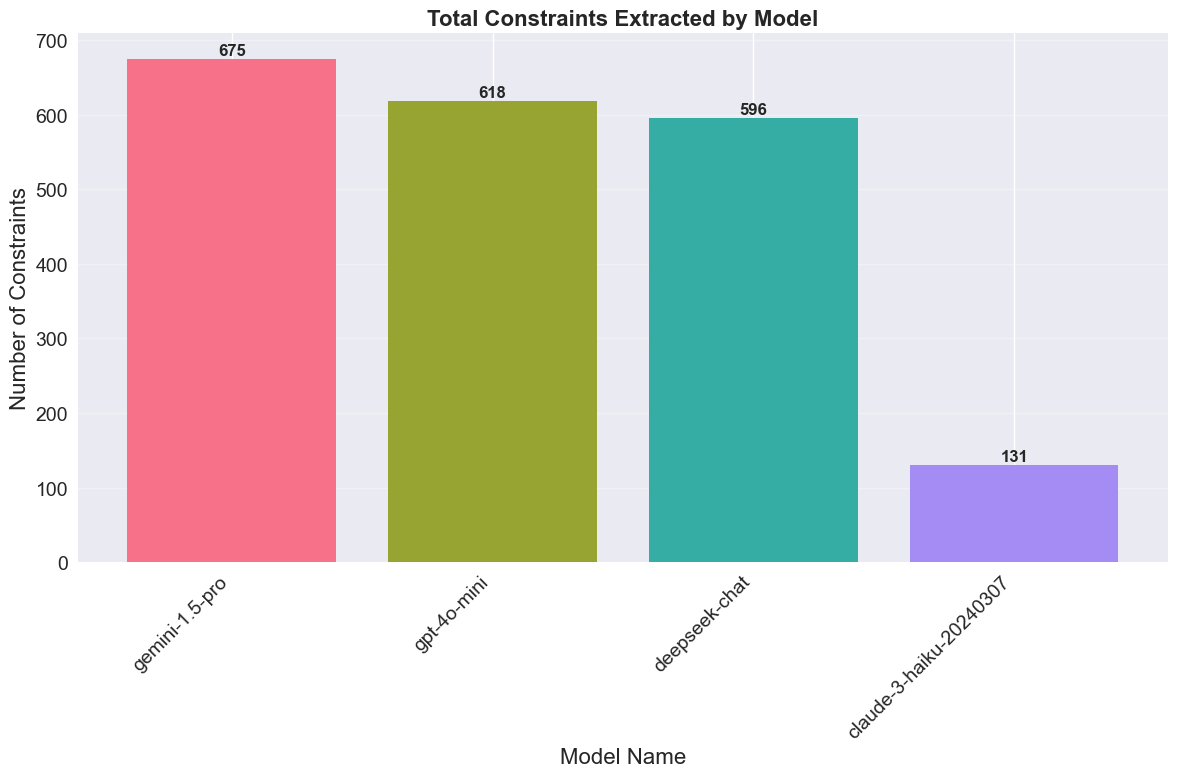

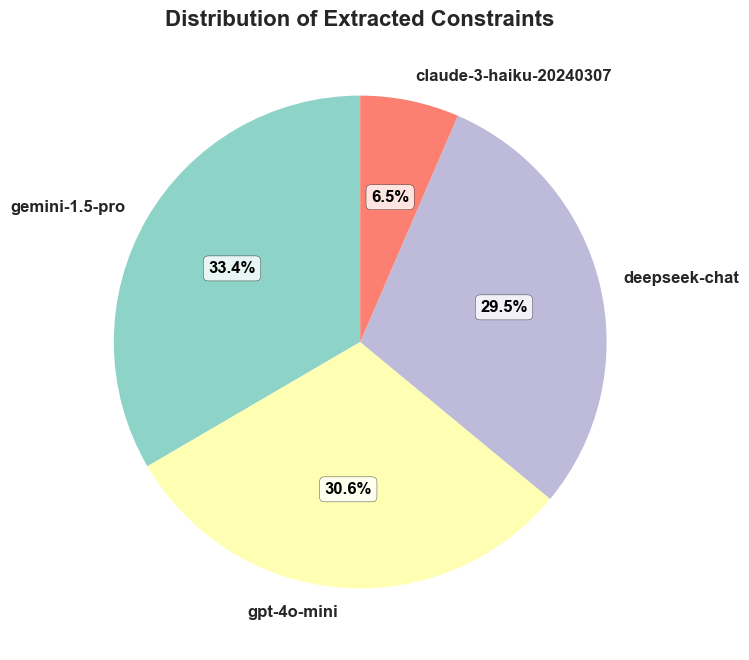

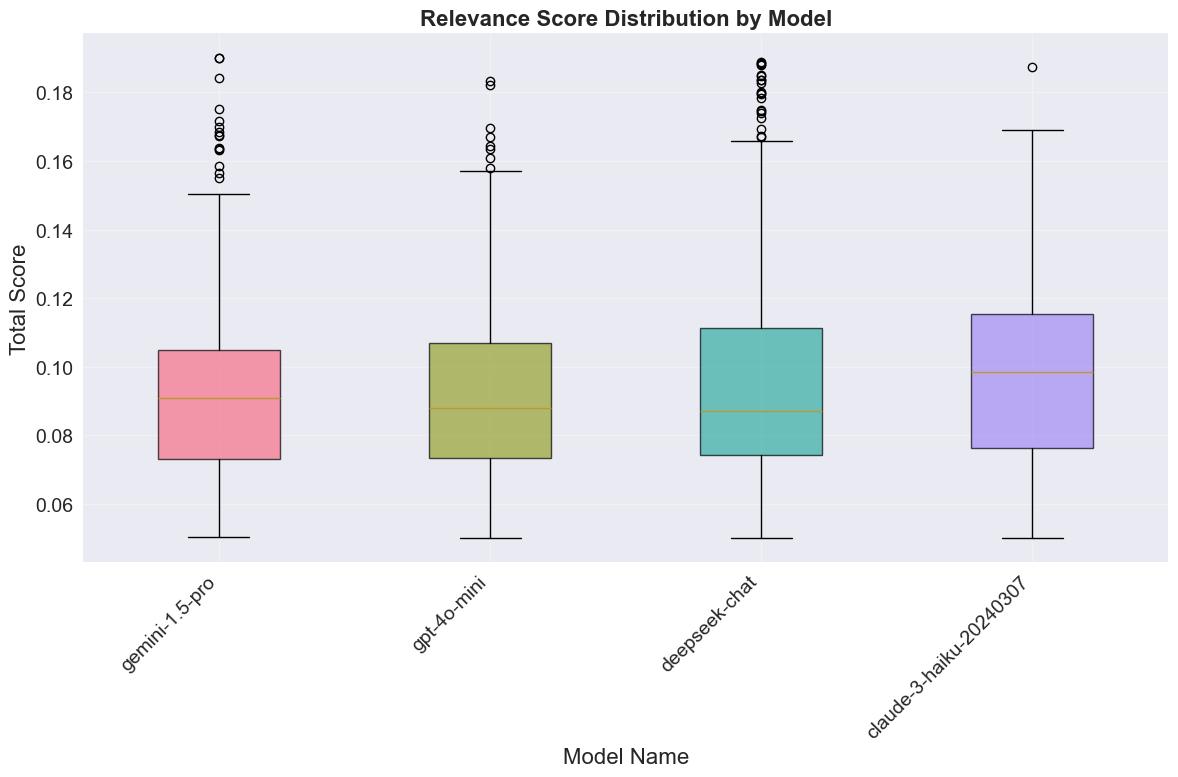

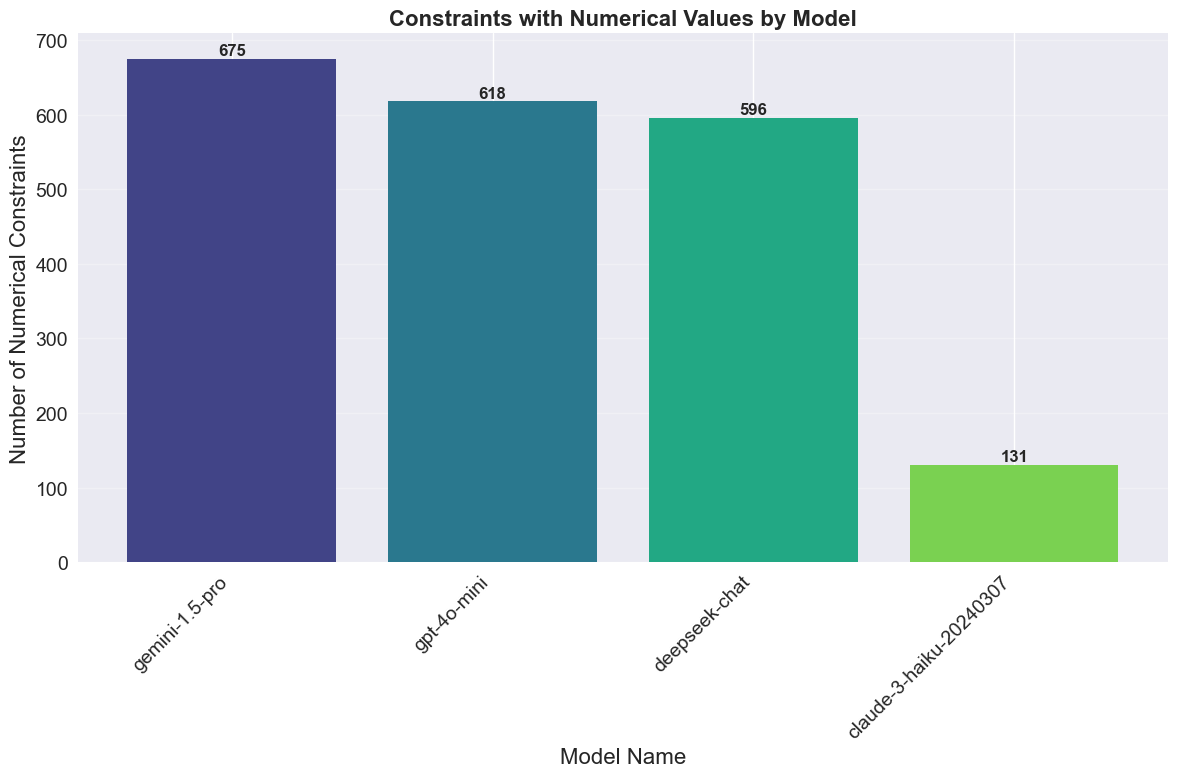

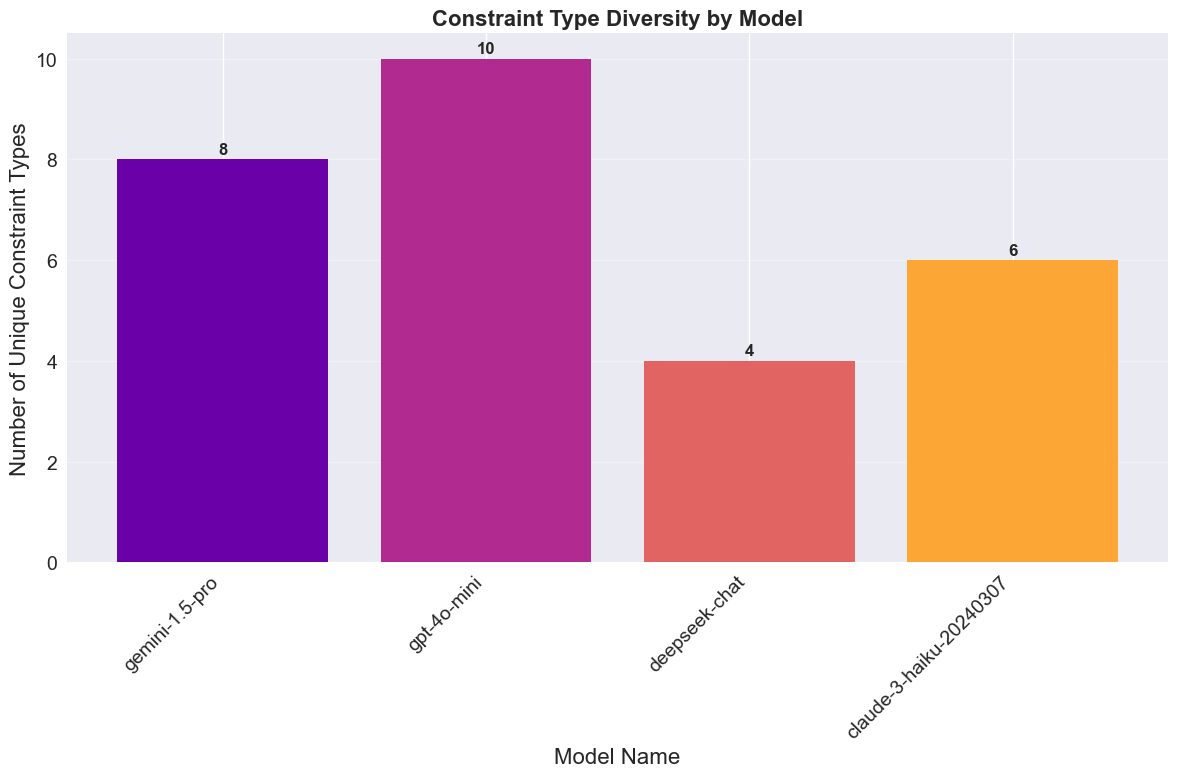

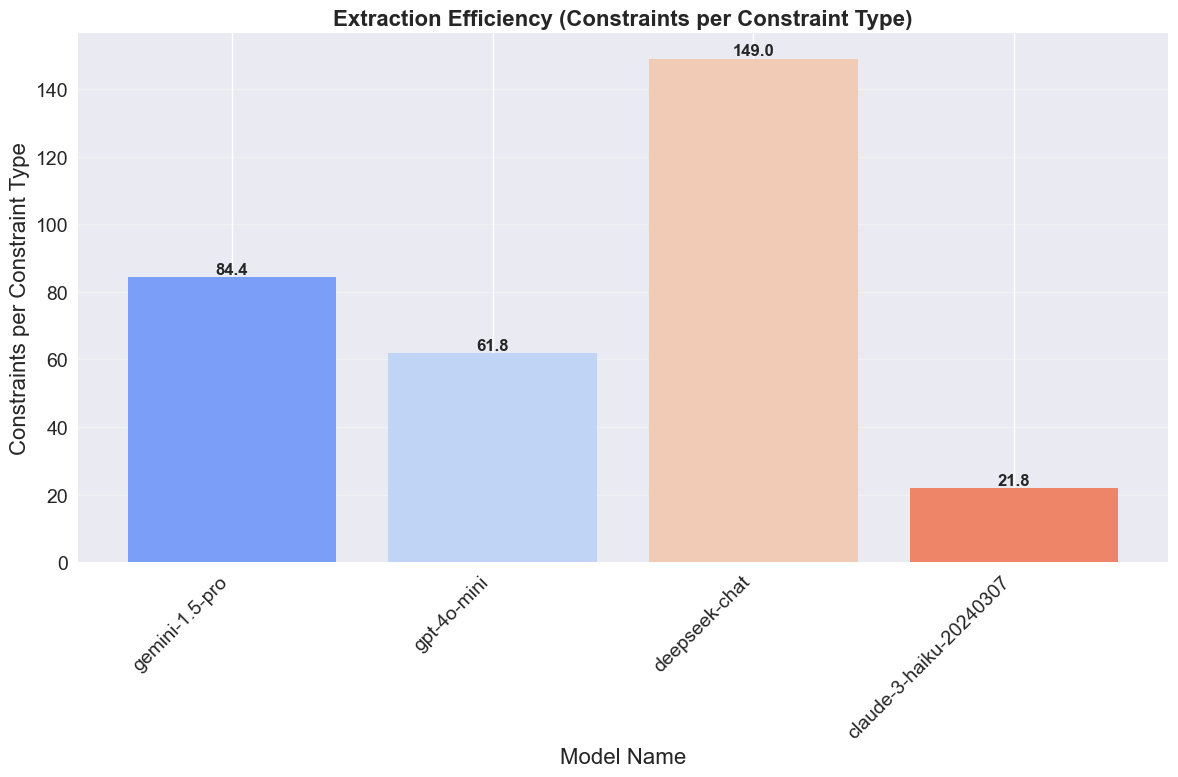

✅ All individual plots have been displayed!

🔬 ADVANCED ANALYSIS PLOTS:


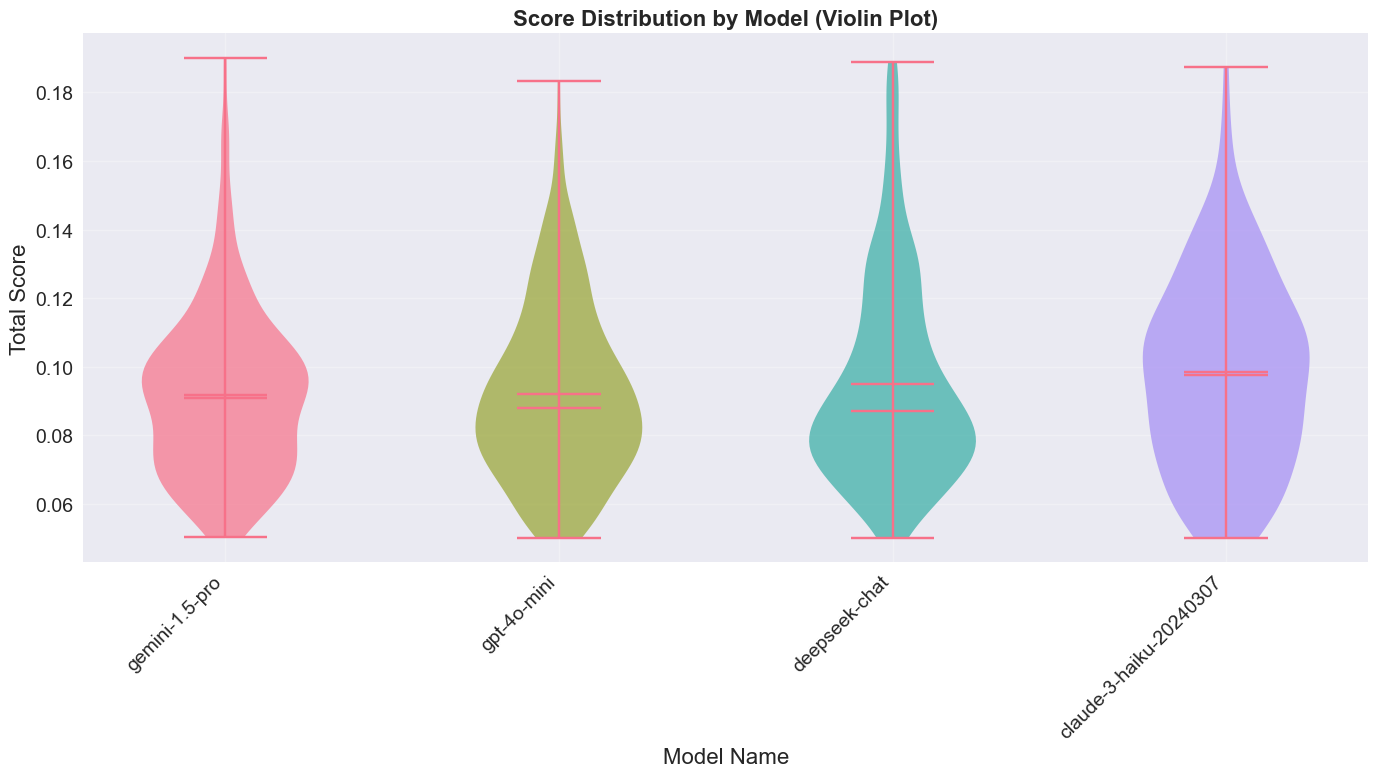

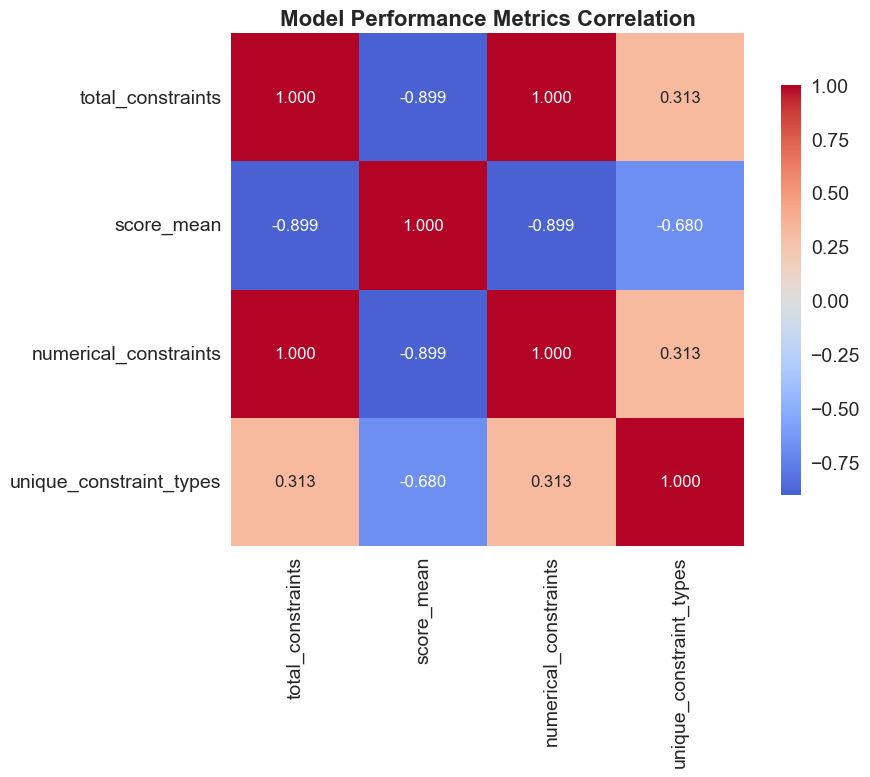

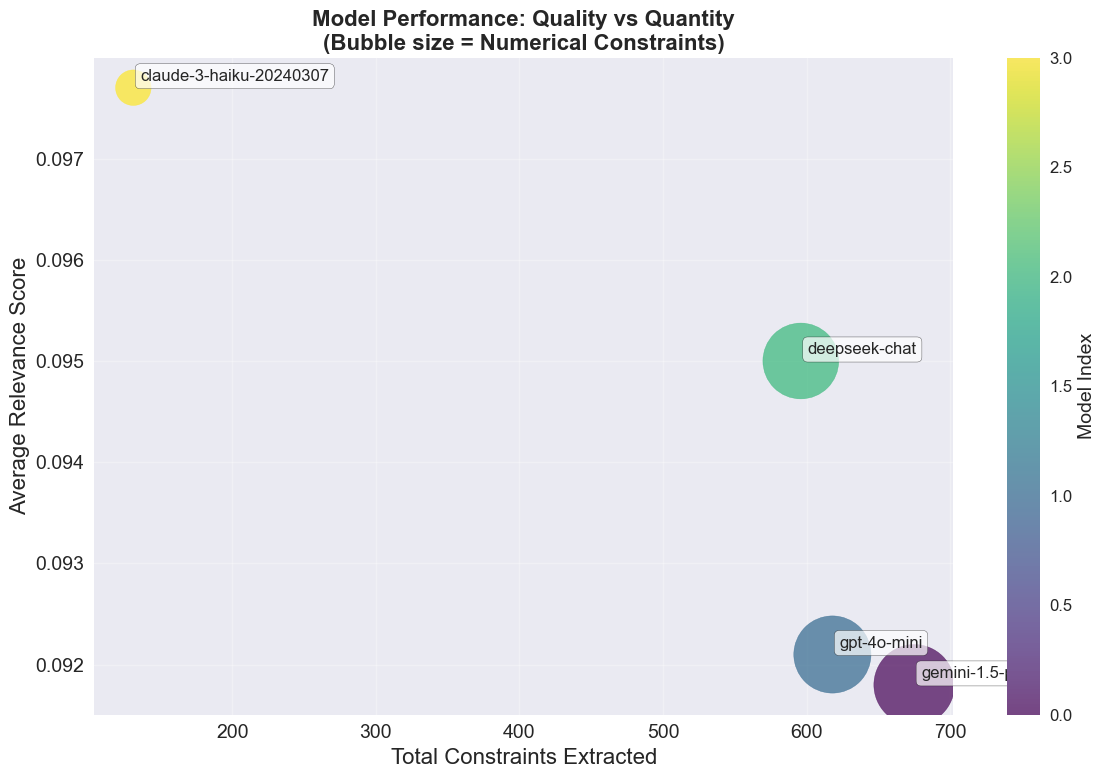

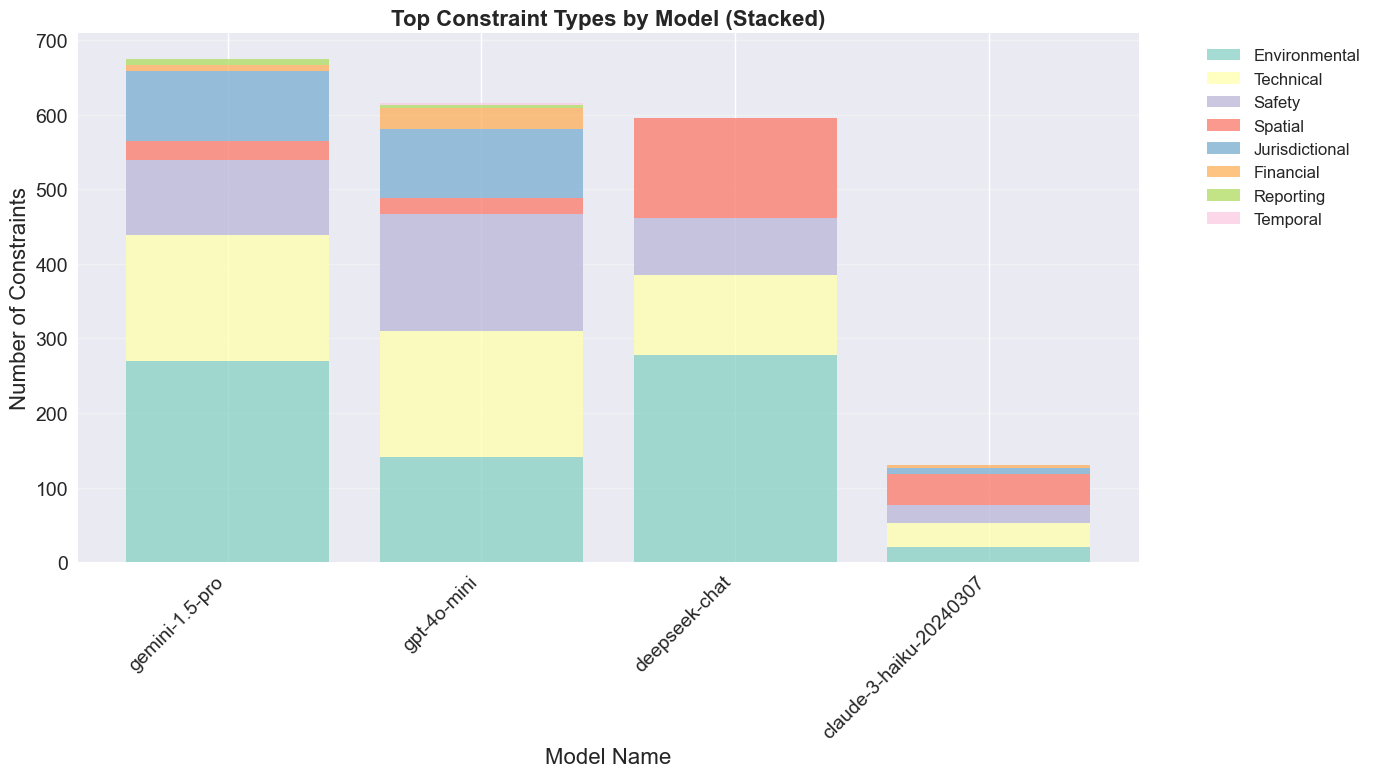

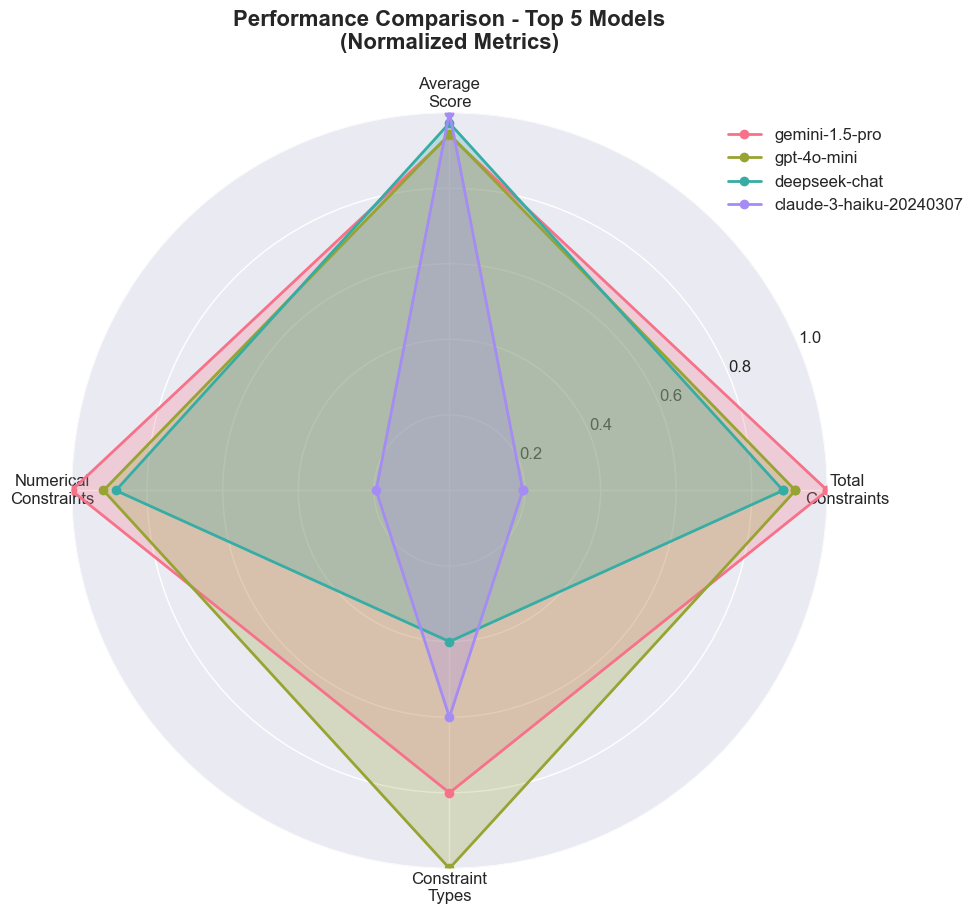

✅ All advanced individual plots have been displayed!

🏆 Generating model ranking...

🏆 MODEL RANKING ANALYSIS
📊 COMPREHENSIVE MODEL RANKING:
Rank  Model                     Score    Constraints  Avg Score  Numerical 
----------------------------------------------------------------------
1     gpt-4o-mini               0.658    618.0        0.092      618.0     
2     gemini-1.5-pro            0.650    675.0        0.092      675.0     
3     deepseek-chat             0.633    596.0        0.095      596.0     
4     claude-3-haiku-20240307   0.350    131.0        0.098      131.0     

📈 RANKING CRITERIA BREAKDOWN:
Criterion                 Weight   Description
--------------------------------------------------
total_constraints         30.0%    Number of constraints extracted
score_mean                30.0%    Average relevance score
numerical_constraints     20.0%    Constraints with numerical values
unique_constraint_types   15.0%    Diversity of constraint types
percentage_of_total

In [3]:
# Initialize the evaluator and run comprehensive analysis
print("🚀 STARTING LLM MODEL EXTRACTION EVALUATION")
print("=" * 60)

# Load data
csv_path = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/LLM/Extract_regulations/Strict_regulations_for_Semantics/combined_all_filtered_constraints.csv"

evaluator = ModelExtractionEvaluator()

if evaluator.load_data(csv_path):
    
    # Define models to exclude from analysis
    models_to_exclude = [
        'gemini-2.5-flash',
        'gpt-4.1', 
        'deepseek-reasoner',
        'gemini-2.5-pro',
        'gpt-4.1-mini'
    ]
    
    print(f"\n🚫 Excluding specified models from analysis...")
    evaluator.exclude_models(models_to_exclude)
    
    print("\n📊 Analyzing remaining model performance...")
    
    # 1. Basic performance analysis
    model_stats = evaluator.analyze_model_performance()
    
    if model_stats is not None and not model_stats.empty:
        print("\n📈 Creating visualization plots...")
        
        # 2. Create individual basic plots
        print("\n🎯 BASIC PERFORMANCE PLOTS:")
        evaluator.create_individual_plots()
        
        print("\n🔬 ADVANCED ANALYSIS PLOTS:")
        # 3. Create advanced individual plots
        evaluator.create_advanced_individual_plots()
        
        # 4. Generate model ranking
        print("\n🏆 Generating model ranking...")
        ranking_results = evaluator.generate_model_ranking()
        
        # 5. Save all results
        print("\n💾 Saving evaluation results...")
        evaluator.save_evaluation_results()
        
        print("\n🎉 MODEL EVALUATION COMPLETE!")
        print("📁 Check the Model_Evaluation folder for detailed results")
        print("📊 All plots have been displayed individually for better analysis")
        print(f"\n🚫 EXCLUDED MODELS: {', '.join(models_to_exclude)}")
        print(f"📊 ANALYZED MODELS: {', '.join(sorted(evaluator.df['model_name'].unique()))}")
        
    else:
        print("❌ No models remain after exclusion or analysis failed")
        
else:
    print("❌ Failed to load data. Please check the file path.")